**EXP4: CNN FOR IMAGE CLASSIFICATION**

In [ ]:
#Step01: Importing libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

#Step02: transform pipeline : preprocessing
transform = transforms.Compose([ #this function chains multiple image transformation
    #.totensor: convert pil image or array to torch, rearranges the dimensions which are originally(height,width,channels) to (channels,height,width),
    #scales picture value(0-255) to 0.0 to 1.0
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)) #0.5 is the center value of(-1,1) so it helps to center around 0
])

#step 03: loading the dataset
#loading the ds cifar10 root = means storing data locally, training = true, download ds if not available and apply transform means preprocessing pipeline
train_dataset = torchvision.datasets.CIFAR10(root ='./data', train = True, download = True, transform = transform)
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle = True) #loads training ds each batch has 64 images and shuffles the data at each epoch

test_dataset = torchvision.datasets.CIFAR10(root = './data', train = False, download = True, transform = transform)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size = 64, shuffle = False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')





In [ ]:
#step04: cnn
class SimpleCNN(nn.Module):
  def __init__(self):#used to define all the layers it runs when model is defined
     super(SimpleCNN,self).__init__() #calls the constructor of parent class
     #conv layer 1: 3 input channels(RGB), 16 filters, 3 x 3 kernel size
     #Feature extraction part (Convolution + pooling)
     self.conv1 = nn.Conv2d(3, 16, kernel_size = 3, padding = 1) #conv layer 1
     #conv layer 2 : 16 input channels, 32 filters, 3 x 3 kernel size
     self.conv2 = nn.Conv2d(16, 32, kernel_size = 3, padding = 1) #conv layer 2
     #pooling layer
     self.pool = nn.MaxPool2d(2, 2) #reduces dimension by half (e.g., 32x32 -> 16x16) , performs max pooling with stride = 2 and kernel_size = 2 x 2

     #Fully connected layer(classifier)
     #After 2 pooling layer the dimensions reduce from 32 x 32 to 8 x 8 i.e 32filters x 8 x 8
     self.fc1 = nn.Linear(32 * 8 * 8, 128) #output has 128 neurons
     self.fc2 = nn.Linear(128, 10) #output is 10 that means 10 classes
     self.relu = nn.ReLU() #activation function

  def forward(self,x): #forward function
      x = self.pool(self.relu(self.conv1(x)))
      x = self.pool(self.relu(self.conv2(x)))
      x = x.view(-1, 32 * 8 * 8) #flatten converts 3d feature map into 1d vector and -1 means automatic calculate batchsize
      x = self.relu(self.fc1(x))
      x = self.fc2(x)
      return x

model = SimpleCNN()

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

for epoch in range(5):
  running_loss = 0.0
  for i,data in enumerate(trainloader,0):
    inputs,labels = data
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  print(f'Epoch {epoch + 1}, Loss: {running_loss / len(trainloader):.3f}')

print('Finished Training')


Epoch 1, Loss: 1.468
Epoch 2, Loss: 1.105
Epoch 3, Loss: 0.964
Epoch 4, Loss: 0.861
Epoch 5, Loss: 0.784
Finished Training


**EXPERIMENT 5: TRANSFER LEARNING USING PRE-TRAINED CNN**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,models

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train / 255.0
y_train = y_train / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
#load pretrained model (transfer learning)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False, #removes original classifier
    weights='imagenet'
)

/tmp/ipykernel_26407/1826740568.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#freeze base layers
base_model.trainable = False

In [ ]:
#Add classifier head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [ ]:
#train model which we frooze at beginning
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history_frozen = model.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - accuracy: 0.0994 - loss: 0.0647 - val_accuracy: 0.1014 - val_loss: 4.6495e-04
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 67ms/step - accuracy: 0.0997 - loss: 2.3482e-04 - val_accuracy: 0.1014 - val_loss: 9.4561e-05
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 78s 63ms/step - accuracy: 0.0997 - loss: 6.2296e-05 - val_accuracy: 0.1014 - val_loss: 3.2868e-05
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.0997 - loss: 2.3757e-05 - val_accuracy: 0.1014 - val_loss: 1.3768e-05
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 78s 62ms/step - accuracy: 0.0997 - loss: 1.0341e-05 - val_accuracy: 0.1014 - val_loss: 6.2531e-06


In [ ]:
#fine tuning the model
base_model.trainable = True

#freeze some layers, train top layers only
for layer in base_model.layers[:-20]:
   layer.trainable=False

In [ ]:
#train again
model.compile(optimizer='Adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

History_finetune = model.fit(x_train, y_train, epochs=5,validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 149s 110ms/step - accuracy: 0.0997 - loss: 1.9133e-09 - val_accuracy: 0.1014 - val_loss: 3.5086e-06
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 130s 101ms/step - accuracy: 0.0997 - loss: 6.5565e-11 - val_accuracy: 0.1014 - val_loss: 2.4560e-06
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 147s 105ms/step - accuracy: 0.0997 - loss: 5.9605e-11 - val_accuracy: 0.1014 - val_loss: 2.9525e-07
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 135s 108ms/step - accuracy: 0.0997 - loss: 2.6822e-11 - val_accuracy: 0.1014 - val_loss: 3.8981e-09
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 126s 101ms/step - accuracy: 0.0997 - loss: 5.9605e-12 - val_accuracy: 0.1014 - val_loss: 5.4836e-10


In [ ]:
#compare accuracy
print("Frozen Accuracy: ",history_frozen.history['val_accuracy'][-1])
print("Fine-tuned Accuracy: ",History_finetune.history['val_accurcay'[-1]])

**Experiment 6: Sequential Models – RNN, LSTM, GRU**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt

In [ ]:
#load imdb dataset
(x_train, y_train),(x_test,y_test) = tf.keras.datasets.imdb.load_data(num_words=10000)

#Pad sequences
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=100)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen=100)

In [ ]:
#Building RNN Model
model_rnn = models.Sequential([
    layers.Embedding(10000, 32, input_length=100),
    layers.SimpleRNN(32),
    layers.Dense(1, activation='sigmoid')
])

model_rnn.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history_rnn = model_rnn.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.6541 - loss: 0.6018 - val_accuracy: 0.7334 - val_loss: 0.5351
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.8396 - loss: 0.3707 - val_accuracy: 0.7978 - val_loss: 0.4575
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9153 - loss: 0.2175 - val_accuracy: 0.7736 - val_loss: 0.5339
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 37ms/step - accuracy: 0.9651 - loss: 0.1034 - val_accuracy: 0.8014 - val_loss: 0.5861
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9866 - loss: 0.0448 - val_accuracy: 0.7672 - val_loss: 0.7844


In [ ]:
#LSTM Model
model_lstm = models.Sequential([
    layers.Embedding(10000,32,input_length=100),
    layers.LSTM(32),
    layers.Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history_lstm = model_lstm.fit(x_train, y_train,epochs=5,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 58ms/step - accuracy: 0.7750 - loss: 0.4522 - val_accuracy: 0.8414 - val_loss: 0.3544
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 45ms/step - accuracy: 0.8928 - loss: 0.2690 - val_accuracy: 0.8412 - val_loss: 0.3655
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.9254 - loss: 0.1964 - val_accuracy: 0.8362 - val_loss: 0.3668
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.9456 - loss: 0.1461 - val_accuracy: 0.8370 - val_loss: 0.4589
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.9625 - loss: 0.1079 - val_accuracy: 0.8404 - val_loss: 0.5194


In [ ]:
#GRU Model
model_gru = models.Sequential([
    layers.Embedding(10000, 32, input_length=100),
    layers.GRU(32),
    layers.Dense(1, activation='sigmoid')
])

model_gru.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history_gru = model_gru.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 55ms/step - accuracy: 0.7650 - loss: 0.4625 - val_accuracy: 0.8452 - val_loss: 0.3638
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.8886 - loss: 0.2745 - val_accuracy: 0.8414 - val_loss: 0.3641
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 47ms/step - accuracy: 0.9220 - loss: 0.2067 - val_accuracy: 0.8456 - val_loss: 0.3701
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.9454 - loss: 0.1522 - val_accuracy: 0.8384 - val_loss: 0.4286
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.9632 - loss: 0.1080 - val_accuracy: 0.8388 - val_loss: 0.5019


In [ ]:
print("RNN:", history_rnn.history['val_accuracy'][-1])
print("LSTM:", history_lstm.history['val_accuracy'][-1])
print("GRU:", history_gru.history['val_accuracy'][-1])

RNN: 0.7671999931335449
LSTM: 0.840399980545044
GRU: 0.8388000130653381


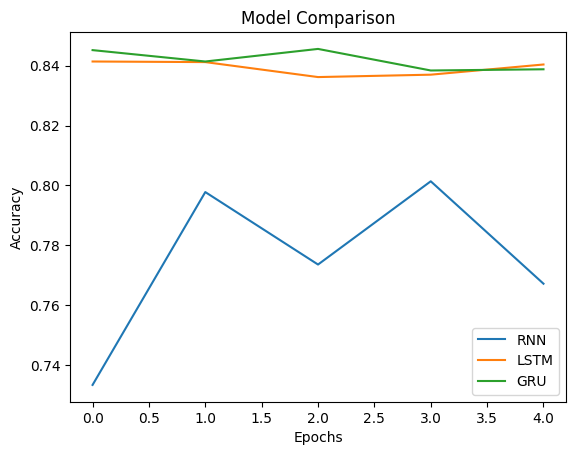

In [ ]:
plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')
plt.plot(history_gru.history['val_accuracy'], label='GRU')

plt.legend()
plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()